21) Partial Autocorrelation (PACF)


In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.graphics.tsaplots import plot_pacf
import seaborn as sns

In [52]:
data = pd.read_csv("../../../data/raw/kathmandu_full_raw_2023_2024.csv")
data['time'] = pd.to_datetime(data['time'])
data = data.sort_values('time')
data.set_index('time', inplace=True)
pm25 = data['pm2_5']

In [40]:
data.head(5)

,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure
time,,,,,,,,,,,
2023-01-01 00:00:00,83.4,119.2,1689,38.0,12.9,67,7.9,88,1.1,162,872.6
2023-01-01 01:00:00,82.2,117.6,1594,31.5,13.2,70,8.0,85,2.9,150,872.3
2023-01-01 02:00:00,80.8,115.7,1504,24.6,13.6,73,8.0,81,4.1,135,871.9
2023-01-01 03:00:00,78.2,112.0,1491,21.5,13.5,72,8.2,76,3.6,135,871.8
2023-01-01 04:00:00,75.7,108.5,1506,19.6,13.2,68,8.3,72,2.3,141,871.8


<Figure size 1000x500 with 0 Axes>

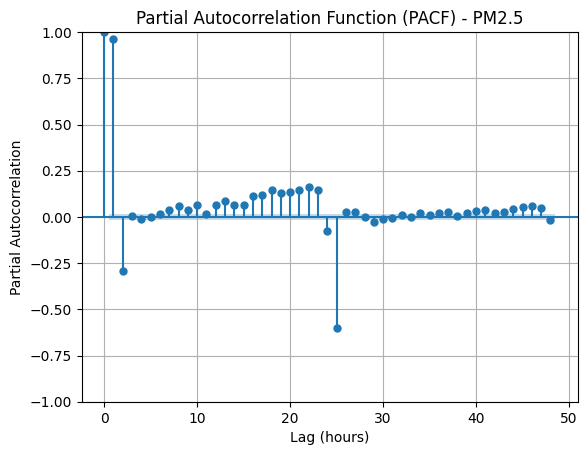

In [41]:
plt.figure(figsize=(10, 5))
plot_pacf(
    pm25,
    lags=48,              # 48 hourly lags = 2 days
    # method='ywm'
)
plt.title('Partial Autocorrelation Function (PACF) - PM2.5')
plt.xlabel('Lag (hours)')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

22. Lag Correlation Analysis


In [42]:
lags = np.arange(1,169, 1)

for lag in lags:
    data[f'pm2_5_lag_{lag}'] = data['pm2_5'].shift(lag)

correlations = {}

for lag in lags:
    corr = data['pm2_5'].corr(data[f'pm2_5_lag_{lag}'])
    correlations[lag] = corr
    
corr_df = pd.DataFrame({
    'Lag (hours)': correlations.keys(),
    'Correlation': correlations.values()
})

corr_df = corr_df.sort_values('Lag (hours)')

print("\nLag Correlation Analysis")
print(corr_df)

/tmp/ipykernel_12804/2738015383.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f'pm2_5_lag_{lag}'] = data['pm2_5'].shift(lag)



Lag Correlation Analysis
     Lag (hours)  Correlation
0              1     0.965610
1              2     0.912207
2              3     0.855741
3              4     0.800283
4              5     0.747344
..           ...          ...
163          164     0.468810
164          165     0.509824
165          166     0.551281
166          167     0.589749
167          168     0.611813

[168 rows x 2 columns]


/tmp/ipykernel_12804/3923002882.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


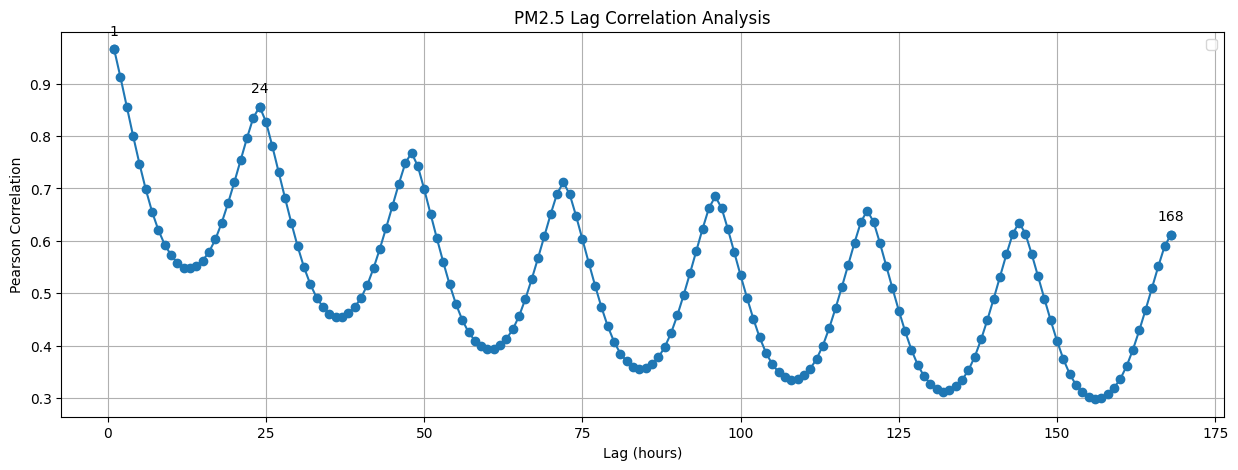

In [43]:
plt.figure(figsize=(15,5))

plt.plot(
    corr_df['Lag (hours)'],
    corr_df['Correlation'],
    marker='o',
    # markersize=3,
    # linewidth=1
)


highlight_lags = [1, 24, 168]
highlight_data = corr_df[corr_df['Lag (hours)'].isin(highlight_lags)]

plt.scatter(
    highlight_data['Lag (hours)'],
    highlight_data['Correlation'],
    # s=20,
    zorder=5,
)

# Add labels
for _, row in highlight_data.iterrows():
    plt.annotate(
        f"{int(row['Lag (hours)'])}",
        (row['Lag (hours)'], row['Correlation']),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )

plt.xlabel('Lag (hours)')
plt.ylabel('Pearson Correlation')
plt.title('PM2.5 Lag Correlation Analysis')
plt.grid(True)
plt.legend()
plt.show()

23. Cross-Correlation Analysis


In [50]:
# data = pd.read_csv("../../../data/raw/kathmandu_full_raw_2023_2024.csv")

# # Convert time column to datetime
# data['time'] = pd.to_datetime(data['time'])
# data = data.sort_values('time').set_index('time')

In [53]:
target = 'pm2_5'
weather_vars = [
    'temperature_2m',
    'relative_humidity_2m',
    'wind_speed_10m',
    'wind_direction_10m',
    'surface_pressure'
]
MAX_LAG = 48

In [ ]:
def cross_correlation(series_x, series_y, max_lag):
   
    lags = np.arange(-max_lag, max_lag + 1)
    correlations = []

    for lag in lags:
        if lag < 0:
            corr = series_x[:lag].corr(series_y[-lag:])
        elif lag > 0:
            corr = series_x[lag:].corr(series_y[:-lag])
        else:
            corr = series_x.corr(series_y)

        correlations.append(corr)

    return lags, correlations

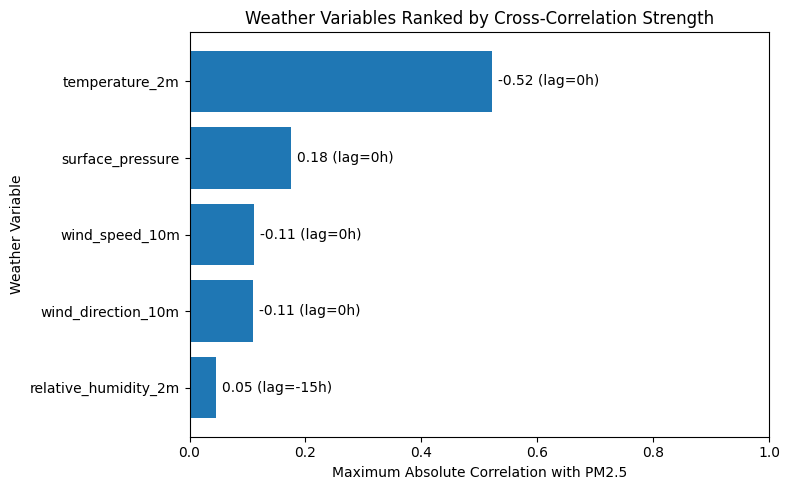

In [66]:
results = []

for var in weather_vars:

    lags, corrs = cross_correlation(
        data[target],
        data[var],
        MAX_LAG
    )

    best_idx = np.nanargmax(np.abs(corrs))

    results.append({
        "Variable": var,
        "Best Lag": lags[best_idx],
        "Correlation": corrs[best_idx],
        "Abs Correlation": abs(corrs[best_idx])
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("Abs Correlation", ascending=True)
)

plt.figure(figsize=(8,5))

bars = plt.barh(
    results_df["Variable"],
    results_df["Abs Correlation"]
)

# Add correlation values on bars
for bar, corr, lag in zip(
    bars,
    results_df["Correlation"],
    results_df["Best Lag"]
):
    plt.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{corr:.2f} (lag={lag}h)",
        va="center"
    )

plt.xlabel("Maximum Absolute Correlation with PM2.5")
plt.ylabel("Weather Variable")
plt.title("Weather Variables Ranked by Cross-Correlation Strength")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

The strongest correlation of a Weather Variable with PM 2.5 is Tempreature at -0.52 (lag = 0hour).
This indicates that there is a strong inverse correlation between PM2.5 and Tempreature.
This can be explained by the seasonal patterns in Kathmandu Valley which is highly polluted in winters when tempreature is lower and is less polluted in summers and monsoon when the tempreature is higher.


temperature_2m
Strongest Absolute Correlation = -0.523
Best lag = 0 hours


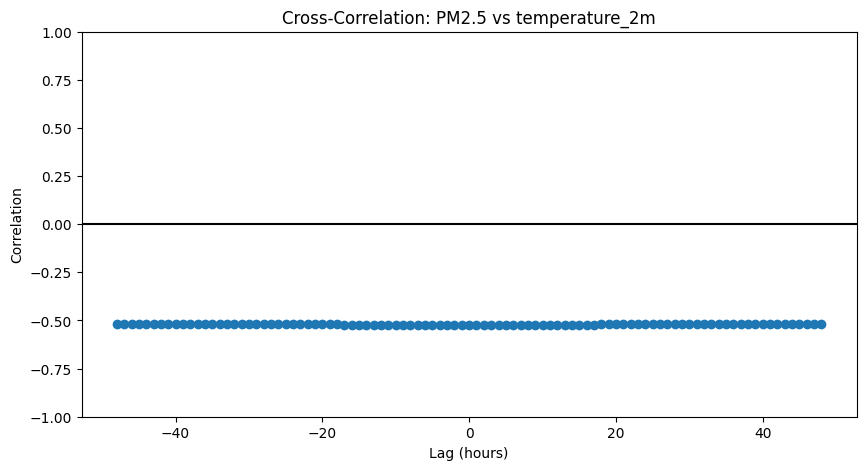


relative_humidity_2m
Strongest Absolute Correlation = 0.046
Best lag = -15 hours


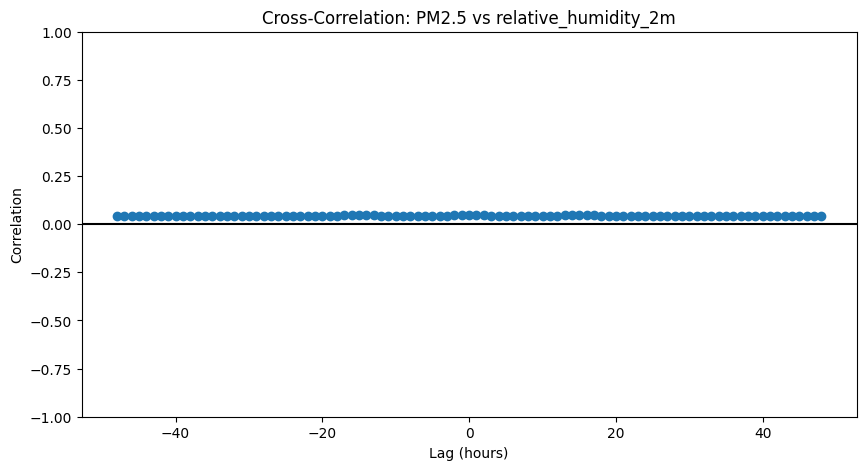


wind_speed_10m
Strongest Absolute Correlation = -0.111
Best lag = 0 hours


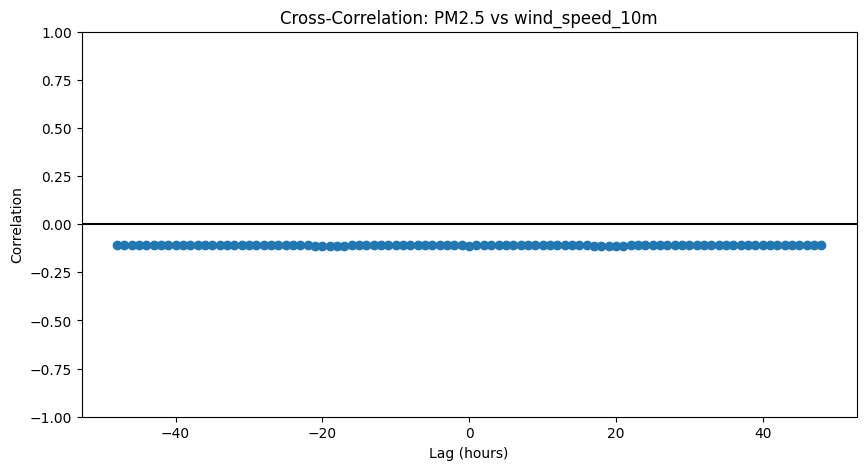


wind_direction_10m
Strongest Absolute Correlation = -0.109
Best lag = 0 hours


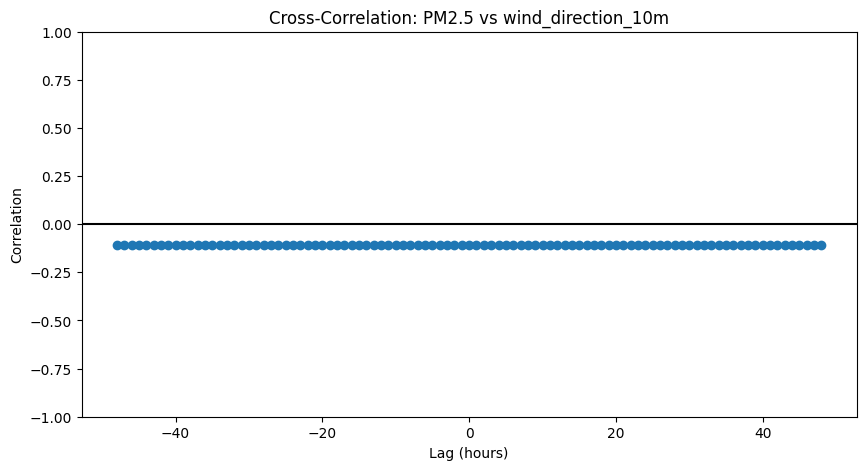


surface_pressure
Strongest Absolute Correlation = 0.176
Best lag = 0 hours


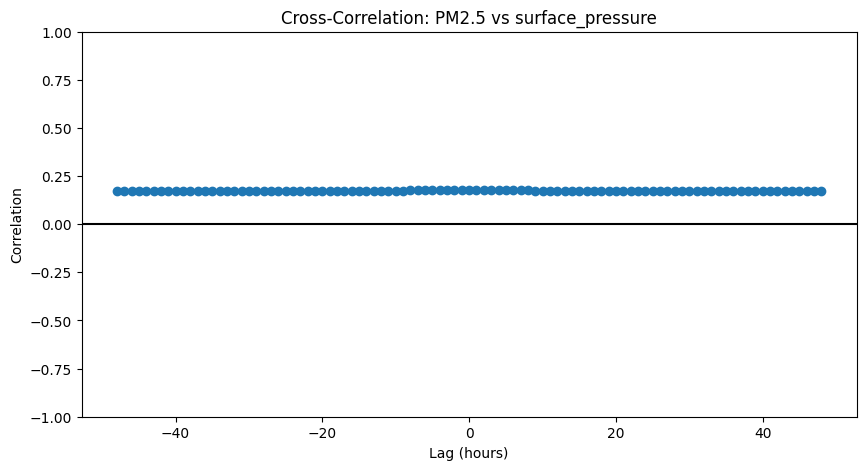

In [ ]:
for var in weather_vars:

    lags, corrs = cross_correlation(
        data[target],
        data[var],
        MAX_LAG
    )

    # Best lag
    best_idx = np.nanargmax(np.abs(corrs))
    best_lag = lags[best_idx]
    best_corr = corrs[best_idx]

    print(f"\n{var}")
    print(f"Strongest Absolute Correlation = {best_corr:.3f}")
    print(f"Best lag = {best_lag} hours")

    plt.figure(figsize=(10, 5))
    plt.plot(lags, corrs, marker='o')
    plt.ylim(-1,1)
    plt.axhline(0, color='black', linestyle='-')
    # plt.axvline(best_lag, color='red', linestyle='--',
    #             label=f'Best Lag = {best_lag}h')
    plt.title(f'Cross-Correlation: PM2.5 vs {var}')
    plt.xlabel('Lag (hours)')
    plt.ylabel('Correlation')
    # plt.legend()
    # plt.grid(True)
    plt.show()